In [1]:
import numpy as np
import pandas as pd
np.set_printoptions(edgeitems=30, linewidth=200) # 적당히 보기 편한 값으로 수정 필요.
from modules.utils import generate_orthonormal_states

import matplotlib
import matplotlib.pyplot as plt
# matplotlib.use('Agg')  # For saving figures
from tqdm import tqdm

dim = 16
number_of_basis = 3
basis_states = generate_orthonormal_states(dim, number_of_basis)
print("Orthogonal states shape:", basis_states.shape)  # (number_of_basis, dim)
assert np.allclose(basis_states @ basis_states.T.conj(), np.eye(number_of_basis)), "state vectors are not orthogonal"

Orthogonal states shape: (3, 16)


In [2]:
from torch.autograd import Variable
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import pennylane as qml

import importlib
from modules import QGAN, Discriminator, MINE  # 초기 import
importlib.reload(QGAN)  # 모듈 갱신
importlib.reload(Discriminator)  # 모듈 갱신
importlib.reload(MINE)  # 모듈 갱신


train_type = "InfoQGAN"
use_mine = True if train_type == "InfoQGAN" else False

G_layers = 5
D_layers = 5
n_qubits = 4
code_qubits = number_of_basis
smooth = 0.0
BATCH_SIZE = 16

ml_device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
quantum_device = qml.device("default.qubit", wires=n_qubits)
print("고전 머신러닝 device =", ml_device, "양자 회로 backend =", quantum_device)

generator_initial_params = Variable(torch.tensor(np.random.normal(-np.pi/3, np.pi/3, (G_layers, n_qubits, 3))), requires_grad=True)
generator = QGAN.QGenerator(n_qubits, n_qubits, G_layers, generator_initial_params, quantum_device, give_me_states=True) # 상태를 얻어야 Discriminator에 넣음.

discriminator_initial_params = Variable(torch.tensor(np.random.normal(-np.pi/2 , np.pi/2, (D_layers, n_qubits, 3))), requires_grad=True)
discriminator = QGAN.QDiscriminator(n_qubits, D_layers, discriminator_initial_params, quantum_device)

mine = MINE.LinearMine(code_dim=code_qubits, output_dim=2**n_qubits, size=100)

고전 머신러닝 device = cpu 양자 회로 backend = <default.qubit device (wires=4) at 0x249c319bca0>


In [3]:
a = discriminator.forward(torch.tensor(basis_states[:number_of_basis]))
print(a, a.dtype)

tensor([0.5096, 0.4732, 0.4325], dtype=torch.float64, grad_fn=<StackBackward0>) torch.float64


In [4]:
def combine_quantum_states(states, train_size, combine_mode):
    # combine given quantum states to generate combined quantum states
    assert combine_mode in ["linspace", "uniform"], "combine_mode should be 'linspace' or 'uniform'"
    num_of_states = len(states)
    dim_of_states = len(states[0])

    if combine_mode == "uniform":
        # use dirichlet distribution to generate random weights
        alpha = np.ones(num_of_states)
        matrix = np.random.dirichlet(alpha, size=train_size)
        coeff = np.sqrt(matrix)
        combined_states = np.dot(coeff, states)
        return combined_states
    
    elif combine_mode == "linspace":
        pass #TODO: linspace방법도 구현한 다음 비교하자. train_size조건이 좀 까다로울듯


In [5]:
train_size = 1000

train_dataset = combine_quantum_states(basis_states, train_size, "uniform")
train_tensor = torch.tensor(train_dataset, dtype=torch.float32)
assert np.allclose(np.linalg.norm(train_dataset, axis=1), np.ones(train_size)), "combined states are not normalized"

C:\Users\minkyu\AppData\Local\Temp\ipykernel_27828\3224583245.py:4: UserWarning: Casting complex values to real discards the imaginary part (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\Copy.cpp:308.)
  train_tensor = torch.tensor(train_dataset, dtype=torch.float32)


In [6]:
G_lr = 0.001
D_lr = 0.0001
M_lr = 0.001
COEFF = 0.1
G_opt = torch.optim.Adam([generator.params], lr=G_lr)
D_opt = torch.optim.Adam([discriminator.params], lr=D_lr)
M_opt = torch.optim.Adam(mine.parameters(), lr=M_lr)

In [7]:
def generator_train_step(generator_seed, coeff, use_mine = False):
    '''
    params (torch.Tensor(레이어,큐빗,3)): a parameter
    generator_input (torch.Tensor(BATCH_SIZE, seed_dim)): 생성기 입력 seed (code+noise).
    '''
    code_input = generator_seed[:, :code_qubits] # 입력중에서 code만 뽑는다. (BATCH_SIZE, code_qubits)
    generator_probs, generator_states = generator.forward(generator_seed) # 출력을 뽑아낸다 (BATCH_SIZE, 2**output_qubits) * 2
    generator_probs = generator_probs.to(torch.float32)
    generator_states = generator_states.to(torch.float32)
    
    disc_output = discriminator.forward(generator_states).to(torch.float32) # quantum discriminator
    gan_loss = torch.log(1-disc_output).mean()
    
    if use_mine:
        pred_xy = mine(code_input, generator_probs)
        code_input_shuffle = code_input[torch.randperm(BATCH_SIZE)]
        pred_x_y = mine(code_input_shuffle, generator_probs)
        mi = torch.mean(pred_xy) - torch.log(torch.mean(torch.exp(pred_x_y)))
        gan_loss -= coeff * mi

    return generator_states, gan_loss

disc_loss_fn = nn.BCELoss()
def disc_cost_fn(real_input, fake_input):
    batch_num = real_input.shape[0]

    disc_real = discriminator.forward(real_input)
    disc_fake = discriminator.forward(fake_input)

    real_label = torch.ones((batch_num, 1)).to(ml_device)
    fake_label = torch.zeros((batch_num, 1)).to(ml_device)
    
    if smooth > 0.00001:
        real_label = real_label - smooth*torch.rand(real_label.shape).to(ml_device)
    
    loss = 0.5 * (disc_loss_fn(disc_real, real_label) + disc_loss_fn(disc_fake, fake_label))
    
    return loss

In [11]:
import seaborn as sns

def visualize_output_simple(gen_states, gen_codes, epoch, writer, image_file_path):
    magnitudes = np.abs(gen_states.detach().numpy().conjugate() @ basis_states.T)**2

    # 1. 첫 번째 플롯: 각 basis_states에 사영시켰을 때, 차지하는 평균 비중 시각화
    avg_magnitudes = magnitudes.mean(axis=0)

    plt.bar(range(number_of_basis), avg_magnitudes)
    plt.title(f"epoch = {epoch}")
    plt.xlabel("Index")
    plt.ylabel("Projection Magnitude")
    # save plt
    writer.add_figure(f'Projection Magnitude', plt.gcf(), epoch)
    plt.savefig(f'{image_file_path}/projection_epoch{epoch:03d}.png')
    plt.close()

    # 2. 두 번째 플롯: 각 code에 대해 basis state의 설명력 시각화
    m, s, d = BATCH_SIZE, n_qubits, number_of_basis
    input_array = gen_codes.detach().numpy()
    output_array = magnitudes

    correlation_matrix = np.zeros((n_qubits, number_of_basis))
    for i in range(n_qubits):
        for j in range(number_of_basis):
            correlation_matrix[i, j] = np.corrcoef(input_array[:, i], output_array[:, j])[0, 1]

    # 시각화
    plt.figure(figsize=(10, 6))
    sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", 
                xticklabels=[f"Basis {j+1}" for j in range(number_of_basis)], 
                yticklabels=[f"Code {i+1}" for i in range(n_qubits)])
    plt.title("Correlation Heatmap between Code and Basis magnitudes (Epoch = {epoch})")
    plt.xlabel("Output Dimensions")
    plt.ylabel("Input Dimensions")
    writer.add_figure(f'Correlation Heatmap', plt.gcf(), epoch)
    plt.savefig(f'{image_file_path}/correlation_heatmap{epoch:03d}.png')
    plt.close()

In [ ]:
import time
import os
from datetime import datetime
from torch.utils.tensorboard import SummaryWriter

current_time = datetime.now().strftime("%b%d_%H_%M_%S")  # "Aug13_14_12_30" 형식
save_dir = f"./runs/pure_{train_type}_{current_time}"
scalar_save_path = os.path.join(save_dir, f"pure_{train_type}_{current_time}.csv")
image_save_dir = os.path.join(save_dir, "images")
param_save_dir = os.path.join(save_dir, "params")
os.makedirs(image_save_dir, exist_ok=True)
os.makedirs(param_save_dir, exist_ok=True)

writer = SummaryWriter(log_dir=save_dir)

In [ ]:
# CSV 파일 초기화 (헤더 작성)
df = pd.DataFrame(columns=['epoch', 'D_loss', 'G_loss', 'MI', 'FD', 'time'])

start_time = time.time()

train_loader = DataLoader(
    TensorDataset(train_tensor),
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True,
    drop_last=True  # 마지막 배치 크기가 작으면 무시
)

epoch_num = 300

for epoch in range(1, epoch_num+1):
    G_loss_sum = 0.0
    D_loss_sum = 0.0
    mi_sum = 0.0
    batch_num = train_size // BATCH_SIZE
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{epoch_num}", unit="batch")

    gen_states = [] # (데이터수, 2**output_qubits) 출력 statevectors
    gen_codes = [] # (데이터수, code_qubits) 코드들
    
    coeff = COEFF # 나중에 epoch별로 coeff다르게 할 때를 위한 코드

    for batch_idx, (batch,) in enumerate(pbar):  # batch unpack
        # train generator
        generator_seed = torch.empty((BATCH_SIZE, n_qubits)).uniform_(-1, 1).to(ml_device) # 이후 np.pi/2 곱해져서 RY 에 들어감
        generator_state, generator_loss = generator_train_step(generator_seed, coeff, use_mine=use_mine)
        G_opt.zero_grad()
        generator_loss.requires_grad_(True)
        generator_loss.backward()
        G_opt.step()
        # train discriminator
        fake_input = generator_state.detach().to(torch.float32)
        disc_loss = disc_cost_fn(batch, fake_input)
        D_opt.zero_grad()
        disc_loss.requires_grad_(True)
        disc_loss.backward()
        D_opt.step()
        # train MINE
        code_input = generator_seed[:, :code_qubits] # (BATCH_SIZE, code_qubits) 코드만 추출
        pred_xy = mine(code_input, fake_input)
        code_input_shuffle = code_input[torch.randperm(BATCH_SIZE)]
        pred_x_y = mine(code_input_shuffle, fake_input)
        mi = -torch.mean(pred_xy) + torch.log(torch.mean(torch.exp(pred_x_y)))
        M_opt.zero_grad()
        mi.requires_grad_(True)
        mi.backward()
        M_opt.step()

        D_loss_sum += disc_loss.item()
        G_loss_sum += generator_loss.item()
        mi_sum -= mi.item() # (-1)곱해져 있어서 빼야함.

        gen_states.append(fake_input.detach().numpy())
        gen_codes.append(code_input.detach().numpy())


In [14]:
import torch
seed = torch.empty((BATCH_SIZE, n_qubits)).uniform_(-np.pi, np.pi)
probs, states = generator.forward(seed)
mag = np.abs(states.detach().numpy().conjugate() @ basis_states.T)**2
print(probs.shape, states.shape, mag.shape)

torch.Size([16, 16]) torch.Size([16, 16]) (16, 3)


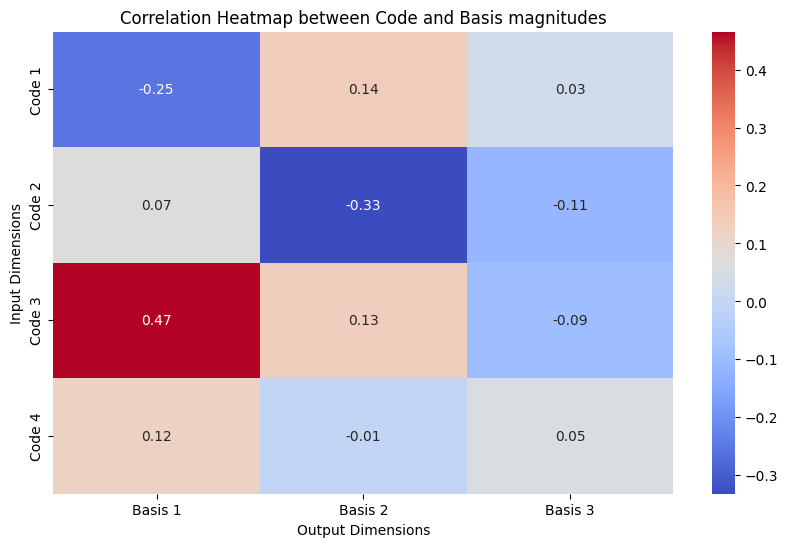

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# (입력: (m, s), 출력: (m, d))
input_array = seed.detach().numpy()
output_array = mag

correlation_matrix = np.zeros((n_qubits, number_of_basis))
for i in range(n_qubits):
    for j in range(number_of_basis):
        correlation_matrix[i, j] = np.corrcoef(input_array[:, i], output_array[:, j])[0, 1]

# 시각화
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", 
            xticklabels=[f"Basis {j+1}" for j in range(number_of_basis)], 
            yticklabels=[f"Code {i+1}" for i in range(n_qubits)])
plt.title("Correlation Heatmap between Code and Basis magnitudes")
plt.xlabel("Output Dimensions")
plt.ylabel("Input Dimensions")
plt.show()

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# 크기 n의 배열 (예제 데이터)
n = 3
data = avg_mag
plt.bar(range(n), data)
plt.title("test")
plt.xlabel("Index")
plt.ylabel("Projection Magnitude")
plt.show()


C:\Users\minkyu\AppData\Local\Temp\ipykernel_25264\3941321672.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [ ]:
basis_states